# About This Notebook

This notebook focuses on training a machine learning model to classify 525 different species of birds, the machine learning model uses pre-trained EfficientNetB0 model with custom layers on top to learn and cliassify the images.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report
from pathlib import Path
import os
import warnings
from datetime import datetime






In [2]:
# Notebook settings
%matplotlib inline
sns.set_style('darkgrid')
warnings.filterwarnings("ignore")

In [4]:
# Define dataset paths (adjust based on your environment)
dataset_path = "200 species"  # Example path for Kaggle dataset
train_dir = os.path.join(dataset_path, "train")
valid_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")

In [5]:
 #Load data into a DataFrame
def load_data(data_dir):
    filepaths = []
    labels = []
    species_folders = sorted(os.listdir(data_dir))
    
    for species in species_folders:
        species_path = os.path.join(data_dir, species)
        if os.path.isdir(species_path):
            for img in os.listdir(species_path):
                img_path = os.path.join(species_path, img)
                filepaths.append(img_path)
                labels.append(species)
    
    return pd.DataFrame({"Filepath": filepaths, "Label": labels})

In [6]:
# Load train, validation, and test data
train_df = load_data(train_dir)
valid_df = load_data(valid_dir)
test_df = load_data(test_dir)

In [7]:
# Exploratory Data Analysis
print("Number of training images:", len(train_df))
print("Number of validation images:", len(valid_df))
print("Number of test images:", len(test_df))
print("Number of unique species:", train_df["Label"].nunique())

Number of training images: 9414
Number of validation images: 9414
Number of test images: 2374
Number of unique species: 200


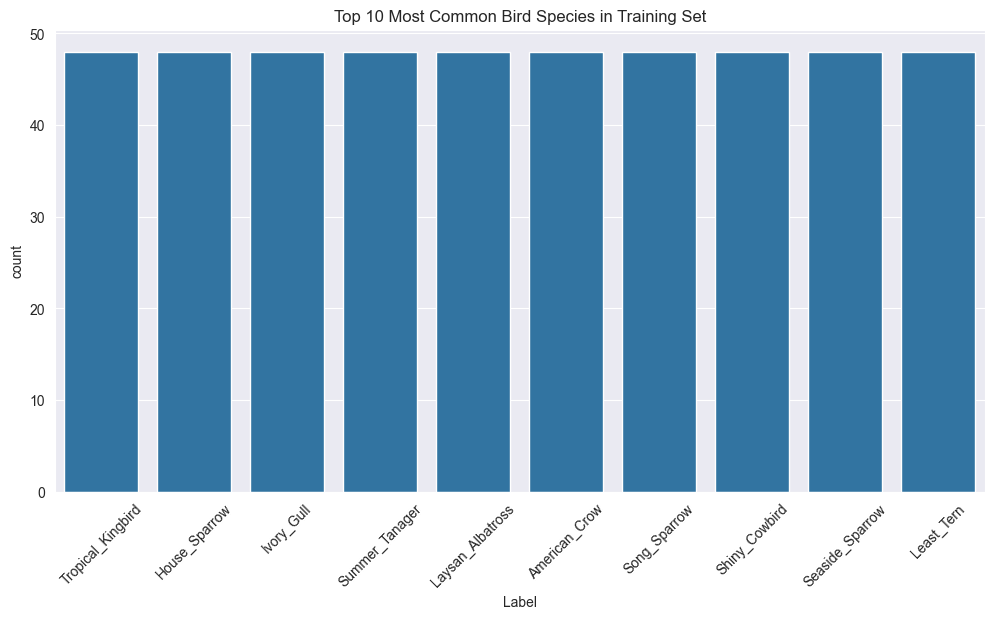

In [8]:
# Plot class distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=train_df, x="Label", order=train_df["Label"].value_counts().index[:10])
plt.title("Top 10 Most Common Bird Species in Training Set")
plt.xticks(rotation=45)
plt.show()


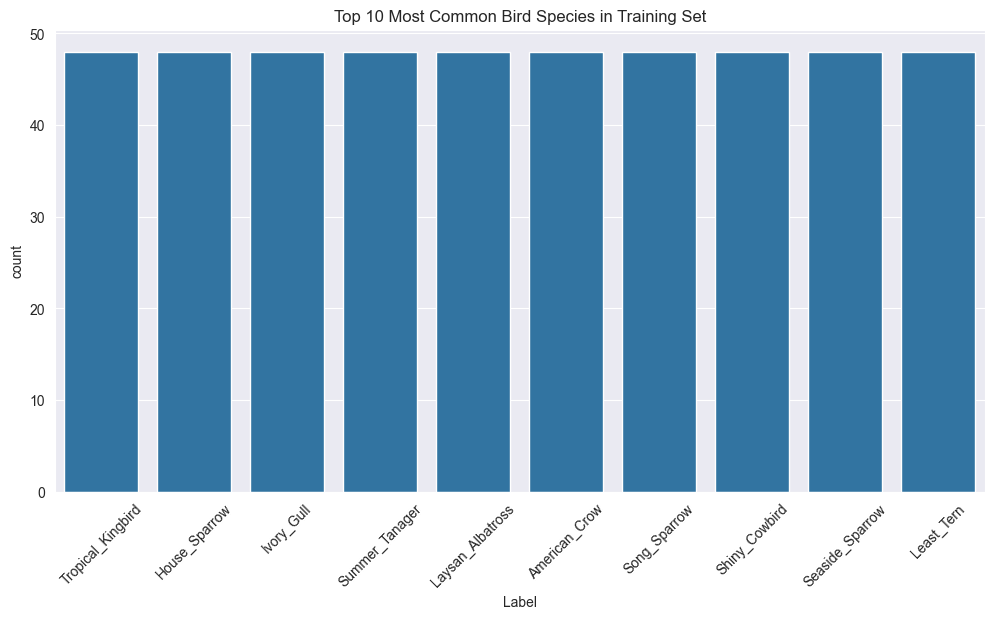

In [9]:
# Plot class distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=train_df, x="Label", order=train_df["Label"].value_counts().index[:10])
plt.title("Top 10 Most Common Bird Species in Training Set")
plt.xticks(rotation=45)
plt.show()


In [10]:
# Data Preprocessing with ImageDataGenerator
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="Filepath",
    y_col="Label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True
)

valid_generator = valid_datagen.flow_from_dataframe(
    valid_df,
    x_col="Filepath",
    y_col="Label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="Filepath",
    y_col="Label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)


Found 9414 validated image filenames belonging to 200 classes.
Found 9414 validated image filenames belonging to 200 classes.
Found 2374 validated image filenames belonging to 200 classes.


In [11]:
# Build CNN Model using MobileNetV2
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model layers

model = tf.keras.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1024, activation="relu"),
    Dropout(0.5),
    Dense(train_df["Label"].nunique(), activation="softmax")
])


In [12]:
# Compile the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
# Define TensorBoard callback
log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,  # Log histograms of weights
    write_graph=True,  # Log model graph
    write_images=True,  # Log model weights as images
    update_freq="epoch"  # Log metrics per epoch
)

# Define callbacks
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("best_model.h5", monitor="val_loss", save_best_only=True),
    tensorboard_callback
]

In [18]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
295/295 [==============================] - 556s 2s/step - loss: 1.4422 - accuracy: 0.5874 - val_loss: 0.6615 - val_accuracy: 0.8119
Epoch 2/10
295/295 [==============================] - 557s 2s/step - loss: 1.4122 - accuracy: 0.5921 - val_loss: 0.6350 - val_accuracy: 0.8222
Epoch 3/10
295/295 [==============================] - 551s 2s/step - loss: 1.4351 - accuracy: 0.5843 - val_loss: 0.6133 - val_accuracy: 0.8282
Epoch 4/10
295/295 [==============================] - 547s 2s/step - loss: 1.4097 - accuracy: 0.5918 - val_loss: 0.6268 - val_accuracy: 0.8292
Epoch 5/10
295/295 [==============================] - 558s 2s/step - loss: 1.4087 - accuracy: 0.5877 - val_loss: 0.5843 - val_accuracy: 0.8397
Epoch 6/10
295/295 [==============================] - 545s 2s/step - loss: 1.3793 - accuracy: 0.5971 - val_loss: 0.5972 - val_accuracy: 0.8314
Epoch 7/10
295/295 [==============================] - 552s 2s/step - loss: 1.3832 - accuracy: 0.5986 - val_loss: 0.5826 - val_accuracy: 0.8420

In [20]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Classification report
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

report = classification_report(y_true, y_pred_classes, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()

75/75 [==============================] - 71s 943ms/step - loss: 1.9226 - accuracy: 0.5173
Test Loss: 1.9226
Test Accuracy: 0.5173
75/75 [==============================] - 66s 887ms/step


In [21]:
# Display top and worst performing classes
def best_classes(df):
    print("Classes with best results:")
    return df.nlargest(10, "f1-score")[["precision", "recall", "f1-score", "support"]]

def worst_classes(df):
    print("Classes with worst results:")
    return df.nsmallest(10, "f1-score")[["precision", "recall", "f1-score", "support"]]

print(best_classes(report_df))
print(worst_classes(report_df))


Classes with best results:
                        precision    recall  f1-score  support
Green_Jay                0.923077  1.000000  0.960000     12.0
Green_Violetear          0.923077  1.000000  0.960000     12.0
Red_breasted_Merganser   1.000000  0.916667  0.956522     12.0
White_Pelican            0.909091  1.000000  0.952381     10.0
Rose_breasted_Grosbeak   0.857143  1.000000  0.923077     12.0
Downy_Woodpecker         1.000000  0.833333  0.909091     12.0
Brown_Pelican            0.846154  0.916667  0.880000     12.0
Geococcyx                0.846154  0.916667  0.880000     12.0
Hooded_Merganser         0.846154  0.916667  0.880000     12.0
Horned_Lark              0.750000  1.000000  0.857143     12.0
Classes with worst results:
                           precision    recall  f1-score  support
Least_Flycatcher            0.000000  0.000000  0.000000     12.0
Tree_Sparrow                0.000000  0.000000  0.000000     12.0
Yellow_bellied_Flycatcher   0.000000  0.000000  0.0000

In [27]:
# Save the model
import wandb

model.save("best_model_final2.h5")
wandb.finish()


In [28]:
# Prediction function
def predict_image_class(model, img_path, class_names):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0  # Rescale
    preds = model.predict(x)
    top_preds = np.argsort(-preds[0])[:5]
    top_probs = preds[0][top_preds]
    
    print("\nTop 5 predicted classes and their probabilities:")
    for i, idx in enumerate(top_preds):
        print(f"{i+1}. {class_names[idx]}: {top_probs[i]*100:.2f}%")

In [29]:
# Example prediction
sample_img = test_df["Filepath"].iloc[0]  # Replace with actual image path if needed
predict_image_class(model, sample_img, class_names)

1/1 [==============================] - 2s 2s/step

Top 5 predicted classes and their probabilities:
1. Acadian_Flycatcher: 49.23%
2. Yellow_bellied_Flycatcher: 18.15%
3. Cerulean_Warbler: 13.72%
4. Black_and_white_Warbler: 12.13%
5. Least_Flycatcher: 2.81%
